 **Cybersecurity Intrusion Detection**

**Coursework 2**  — Predictive Modeling, Advanced Evaluation & Explainable AI (XAI)**

**Course**: Master's in Information Systems

**Dataset**:`cybersecurity_intrusion_data.csv` (9,537 network sessions)

**Target Variable**: `attack_detected` (1 = Attack, 0 = Normal)

**Platform**: Jupyter Notebook
**Student Names** Niyongabo Queenthia Olga 2025/MSIS/045/PS 
                  Siama Mary 2025/MSIS/044/PS 
                  Kyogabirwe Scovia 2025/PGD/002/PS



# Re-run Preprocessing Pipeline
This section re-runs the exact same preprocessing steps from Course Work-1 so that
the cleaned, encoded, scaled, and SMOTE-balanced data is available for modelling.


In [1]:
# Install required libraries
!pip install imbalanced-learn shap xgboost -q
print('Libraries installed')


Libraries installed


**Why we installed these libraries:**
- `imbalanced-learn: provides SMOTE for balancing the training set
- `shap`: provides Explainable AI tools
- `xgboost`: provides the XGBoost model trained
- `-q` means quiet mode (less printed text)


In [2]:
#  All imports

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 110

# Preprocessing 
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Machine Learning Models 
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics 
from sklearn.metrics import (
    average_precision_score,    # for PR-AUC
    precision_recall_curve,     # for drawing PR curve
    roc_auc_score,              # for ROC-AUC
    roc_curve,                  # for drawing ROC curve
    classification_report,      # precision, recall, F1 table
    confusion_matrix,           # correct vs wrong predictions
    PrecisionRecallDisplay       # PR curve chart helper
)

# Explainable AI (new in CW2)
import shap

import warnings
warnings.filterwarnings('ignore')

print('All imports successful')


All imports successful


**Explanation:**
- This cell loads every tool needed.
- Libraries carried forward: `pandas`, `numpy`, `sklearn` preprocessing tools, `SMOTE`.
- New libraries added: `RandomForestClassifier`, `xgboost`, evaluation metrics, `shap`.


In [3]:
# Load data

df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.drop('session_id', axis=1, inplace=True) # session_id is a row label 

print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print('Target distribution:')
print(df['attack_detected'].value_counts())


Loaded: 9,537 rows, 10 columns
Target distribution:
attack_detected
0    5273
1    4264
Name: count, dtype: int64


# Explanation
We have loaded the dataset to view its shape, columns and rows, session_id is dropped because it is a raw label.

In [4]:
# Imputation

df['encryption_used'] = df['encryption_used'].fillna('None')

# KNN Imputation for numeric columns (demonstrated per CW1 requirement)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != 'attack_detected']
knn_imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = knn_imputer.fit_transform(df[numeric_cols])

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('Imputation complete.')

Missing values remaining: 0
Imputation complete.


# EXplanation
encryption_used NaN = MNAR (Missing Not At Random) was filled with None.
We fill with 'None' to explicitly represent unencrypted session

In [5]:
# Encoding

cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Shape after encoding: {df_encoded.shape}')
print('Columns:', list(df_encoded.columns))


Shape after encoding: (9537, 15)
Columns: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'attack_detected', 'protocol_type_TCP', 'protocol_type_UDP', 'encryption_used_DES', 'encryption_used_None', 'browser_type_Edge', 'browser_type_Firefox', 'browser_type_Safari', 'browser_type_Unknown']


# Explanation
we used One-Hot Encoding for all nominal (unordered) categorical columns.
drop_first=True avoids the dummy variable trap (redundant column removed per group)

In [6]:
# SPLIT FEATURES AND TARGET 
# X = all columns except the target
# y = the target column (0 = Normal, 1 = Attack)

X = df_encoded.drop('attack_detected', axis=1)
y = df_encoded['attack_detected']

# STRATIFIED TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'Attack ratio in train: {y_train.mean():.4f}')
print(f'Attack ratio in test : {y_test.mean():.4f}')
print('(Ratios match; stratify=y worked correctly)')


Training set : 7,629 rows
Test set     : 1,908 rows
Attack ratio in train: 0.4471
Attack ratio in test : 0.4471
(Ratios match; stratify=y worked correctly)


# Explanation
 we used 80% for training and 20% used for testing
both sets keep the same Normal:Attack ratio as the full dataset
we fixed random_state=42 so that the results are reproducible every time

In [7]:
#FEATURE SCALING

num_feature_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()

X_train[num_feature_cols] = scaler.fit_transform(X_train[num_feature_cols])
X_test[num_feature_cols]  = scaler.transform(X_test[num_feature_cols])

# .fit_transform on train: learns mean/std AND scales
# .transform on test: this applies the SAME mean/std learned from training

print('Scaling complete.')


Scaling complete.


# Explanation
Fitting the scaler on both the trained and test is a data leakage mistake. 
therefore this fits only on training data and transforms both sets


In [8]:
# SMOTE (applied on the training set only)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
# fit_resample: generates synthetic minority rows until classes are equal

print('SMOTE complete.')
print(f'Training set before SMOTE: {X_train.shape[0]:,} rows')
print(f'Training set after  SMOTE: {X_train_sm.shape[0]:,} rows')
print(f'\nNew class distribution (training):')
print(pd.Series(y_train_sm).value_counts().sort_index())
print()
print('Preprocessing pipeline complete: ready for modelling!')


SMOTE complete.
Training set before SMOTE: 7,629 rows
Training set after  SMOTE: 8,436 rows

New class distribution (training):
attack_detected
0    4218
1    4218
Name: count, dtype: int64

Preprocessing pipeline complete: ready for modelling!


# Explanation 
SMOTE creates synthetic attack examples to balance the training set applied only to training data (test set must reflect real-world imbalance)

**Outcome of preprocessing pipeline:**
- Dataset loaded and `session_id` dropped (no predictive value).
- `encryption_used` NaN filled with `'None'` (MNAR, domain-informed).
- KNN Imputation applied to numeric columns.
- All categorical columns converted to 0/1 via One-Hot Encoding.
- Stratified 80/20 train/test split (same class ratio in both sets).
- StandardScaler fitted on training data, applied to both sets.
- SMOTE applied to training set only - test set left as-is.
- Final training set: **balanced**
- Test set: **original distribution**


# Part 1 - Algorithm selection and training

**Why these two algorithms?**

Comparing multiple algorithms to understand the tradeoff between interpretability and predictive performance.

| Algorithm | Type | How It Works | Strength | Limitation |
|---|---|---|---|---|
| **Random Forest** | Ensemble (parallel) | Builds 400 independent decision trees; final answer = majority vote | Simple to understand, robust, fast | Slightly lower accuracy than boosting |
| **XGBoost** | Ensemble (sequential boosting) | Each new tree corrects the mistakes of the previous one | Usually highest accuracy; handles imbalance well | More complex; more hyperparameters |

### Why we used ensemble methods for cybersecurity?
- Network traffic data has complex, non-linear patterns that simple models (logistic regression) miss.
- Both models are robust to outliers - important because attack traffic produces anomalous values.
- Both are resistant to overfitting through their ensemble structure.

### Class imbalance handling strategy:
- We applied SMOTE to the training data.
- Additionally: `class_weight='balanced'` in Random Forest and `scale_pos_weight` in XGBoost
  provide a second layer of protection at the algorithm level.


In [9]:
# RANDOM FOREST CLASSIFIER

rf_model = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# .fit() is the training step

print('Training Random Forest on', X_train_sm.shape[0], 'samples...')
rf_model.fit(X_train_sm, y_train_sm)
print('Random Forest training complete!')


Training Random Forest on 8436 samples...
Random Forest training complete!


**Explanation:**
- `RandomForestClassifier(...)` creates the model object - nothing is trained yet.
- `.fit(X_train_sm, y_train_sm)` is the actual training: the model reads each row
  and builds its 400 decision trees.
- We train on `X_train_sm` and `y_train_sm` - the SMOTE-balanced versions.



In [10]:
# Calculate scale_pos_weight BEFORE SMOTE (original training distribution)

neg_count = int((y_train == 0).sum())   # count of Normal sessions in training
pos_count = int((y_train == 1).sum())   # count of Attack sessions in training
spw = float(neg_count) / pos_count      # scale_pos_weight ratio

print(f'Original training set:')
print(f'  Normal  (0): {neg_count:,}')
print(f'  Attack  (1): {pos_count:,}')
print(f'  scale_pos_weight = {neg_count}/{pos_count} = {spw:.4f}')
print()
print('Interpretation:')
print(f'  XGBoost will treat each Attack instance as {spw:.2f}x as important as Normal')


Original training set:
  Normal  (0): 4,218
  Attack  (1): 3,411
  scale_pos_weight = 4218/3411 = 1.2366

Interpretation:
  XGBoost will treat each Attack instance as 1.24x as important as Normal


# Explanation 
We used the original y_train counts, not the SMOTE-balanced ones
because scale_pos_weight is meant to reflect real-world class imbalance

In [11]:
# XGBOOST CLASSIFIER

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    scale_pos_weight=spw,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

print('Training XGBoost on', X_train_sm.shape[0], 'samples')
xgb_model.fit(X_train_sm, y_train_sm)
print('XGBoost training complete')


Training XGBoost on 8436 samples
XGBoost training complete


**Explanation:**
- `xgb.XGBClassifier(...)` creates the model with all its settings (hyperparameters).
- `.fit(X_train_sm, y_train_sm)` trains all 400 sequential trees on the balanced data.
- `verbosity=0` suppresses XGBoost's internal training messages for cleaner output.
- XGBoost takes slightly longer than Random Forest because trees are built one at a time.


# Training Summary Comparison


In [12]:
# Quick sanity check: making training predictions to verify both models learned something

rf_train_acc  = rf_model.score(X_train_sm, y_train_sm)
xgb_train_acc = xgb_model.score(X_train_sm, y_train_sm)

rf_test_acc   = rf_model.score(X_test, y_test)
xgb_test_acc  = xgb_model.score(X_test, y_test)

print('=' * 55)
print(f'{"":<22} {"Random Forest":>15} {"XGBoost":>15}')
print('=' * 55)
print(f'{"Training Accuracy":<22} {rf_train_acc:>14.4f} {xgb_train_acc:>15.4f}')
print(f'{"Test Accuracy":<22} {rf_test_acc:>14.4f} {xgb_test_acc:>15.4f}')
print(f'{"Num Features Used":<22} {X_train_sm.shape[1]:>14} {X_train_sm.shape[1]:>15}')
print(f'{"Training Samples":<22} {X_train_sm.shape[0]:>14,} {X_train_sm.shape[0]:>15,}')
print('=' * 55)
print()



                         Random Forest         XGBoost
Training Accuracy              1.0000          0.9815
Test Accuracy                  0.8836          0.8700
Num Features Used                  14              14
Training Samples                8,436           8,436



# Explanation
Accuracy alone is NOT enough for imbalanced datasets.
A model predicting all Normal would get ~55% accuracy and catch ZERO attacks
We use PR-AUC and F1-Score for a proper evaluation.

## Part 2: Advanced Evaluation Metrics 

Metrics designed for imbalanced classification:
-Precision
-Recall
-F1-Score
-PR-AUC

In [13]:
# Generating Predictions
# Generated two types of predictions from the test set:
#
# predict_proba() -> returns PROBABILITY scores for each class
#   Output shape: (n_rows, 2)  -> column 0 = prob of Normal, column 1 = prob of Attack
#   We take [:, 1] to get the attack probability for every session
#   These probabilities are needed for PR-AUC (it needs a continuous score)
#
# predict() -> returns hard LABELS (0 or 1) using a default 0.5 threshold
#   If attack probability >= 0.5 -> predict Attack (1)
#   If attack probability <  0.5 -> predict Normal (0)
#   These are used for confusion matrix and classification report

rf_probs  = rf_model.predict_proba(X_test)[:, 1]   # RF attack probabilities
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]  # XGB attack probabilities

rf_preds  = rf_model.predict(X_test)   # RF hard labels (0 or 1)
xgb_preds = xgb_model.predict(X_test)  # XGB hard labels (0 or 1)

print(f'Predictions generated for {len(y_test):,} test sessions.')
print()
print('Sample of XGBoost probability scores (first 10):')
print(np.round(xgb_probs[:10], 4))
print('Corresponding hard predictions:')
print(xgb_preds[:10])
print('Actual labels:')
print(y_test.values[:10])


Predictions generated for 1,908 test sessions.

Sample of XGBoost probability scores (first 10):
[0.9848 0.9999 0.9996 0.0605 0.1204 0.2302 0.999  0.1171 0.3049 0.0303]
Corresponding hard predictions:
[1 1 1 0 0 0 1 0 0 0]
Actual labels:
[1 1 1 0 0 0 1 1 0 0]


**Explanation:**
- The probability scores (e.g., 0.9231) represent how confident the model is that a session is an attack.
- A score of 0.9231 means: 'I am 92.3% confident this session is an attack'.
- Scores are converted to 0/1 labels by comparing to the 0.5 threshold.
- PR-AUC uses the raw probability scores (not the 0/1 labels) so it evaluates the model
  across ALL possible thresholds, not just 0.5.


In [14]:
# Calculate PR-AUC scores
# average_precision_score = area under the Precision-Recall curve

rf_prauc  = average_precision_score(y_test, rf_probs)
xgb_prauc = average_precision_score(y_test, xgb_probs)

print('=' * 50)
print('  PR-AUC SCORES  (range: 0 to 1, higher = better)')
print('=' * 50)
print(f'  Random Forest PR-AUC : {rf_prauc:.4f}  ({rf_prauc*100:.2f}%)')
print(f'  XGBoost       PR-AUC : {xgb_prauc:.4f}  ({xgb_prauc*100:.2f}%)')
print('=' * 50)

winner = 'XGBoost' if xgb_prauc > rf_prauc else 'Random Forest'
diff   = abs(xgb_prauc - rf_prauc)
print(f'\nBetter model by PR-AUC: {winner} (by {diff:.4f} points)')
print()


  PR-AUC SCORES  (range: 0 to 1, higher = better)
  Random Forest PR-AUC : 0.9063  (90.63%)
  XGBoost       PR-AUC : 0.9093  (90.93%)

Better model by PR-AUC: XGBoost (by 0.0031 points)



# Explanation
 PR-AUC = 1.0 : perfect detector (every attack caught, no false alarms)
 PR-AUC = 0.5 : random guessing
 Our scores tell us how well each model balances catching attacks vs false alarms

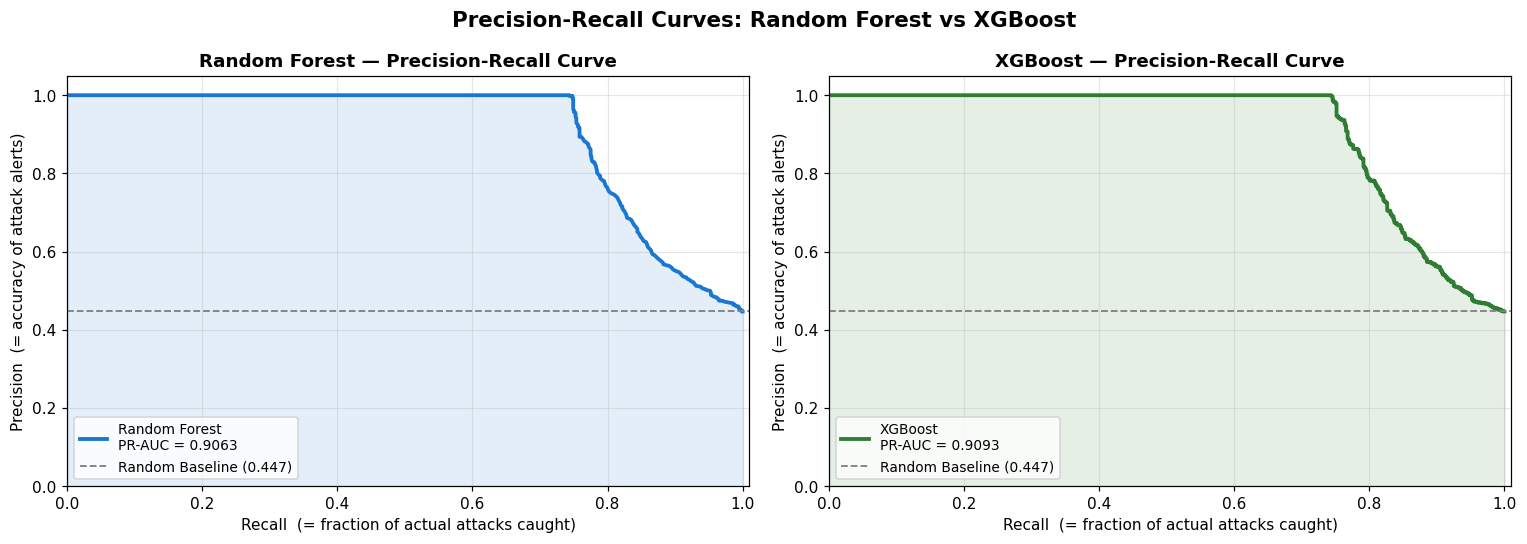

In [15]:
# Draw the Precision-Recall curves for both models side by side
#
# A PR curve plots Precision (y-axis) against Recall (x-axis) at every threshold
# The AREA under this curve = PR-AUC score
# A curve closer to the TOP-RIGHT corner = better model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_info = [
    (axes[0], rf_probs,  'Random Forest', '#1976D2', rf_prauc),
    (axes[1], xgb_probs, 'XGBoost',       '#2E7D32', xgb_prauc),
]

for ax, probs, name, color, prauc in model_info:
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, probs)
    # precision_recall_curve returns three arrays:
    #   precision_vals : precision at each threshold
    #   recall_vals    : recall at each threshold
    #   thresholds     : the probability thresholds tested

    ax.plot(recall_vals, precision_vals, color=color, linewidth=2.5,
            label=f'{name}\nPR-AUC = {prauc:.4f}')

    # Add a baseline: a random classifier's PR curve
    baseline = y_test.mean()  # proportion of positive class
    ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1.2,
               label=f'Random Baseline ({baseline:.3f})')

    # Shade the area under the curve
    ax.fill_between(recall_vals, precision_vals, alpha=0.12, color=color)

    ax.set_title(f'{name} — Precision-Recall Curve', fontweight='bold', fontsize=12)
    ax.set_xlabel('Recall  (= fraction of actual attacks caught)', fontsize=10)
    ax.set_ylabel('Precision  (= accuracy of attack alerts)', fontsize=10)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Precision-Recall Curves: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Explanation

How to read this chart:
 X-axis (Recall)    = fraction of real attacks we caught
 Y-axis (Precision) = fraction of our "attack" alerts that were real
 Dashed line        = a random classifier (baseline to beat)
 Shaded area        = the PR-AUC (larger = better)
 Curve closer to TOP-RIGHT corner = better model

# Confusion Matrices

The confusion matrix shows the exact count of correct and incorrect predictions.
It breaks down performance into four quadrants so we can see where the model fails.


Random Forest:
  True  Negatives  (TN) = 1047  -- Normal correctly identified
  False Positives  (FP) =    8  -- False alarms (normal flagged as attack)
  False Negatives  (FN) =  214  -- MISSED ATTACKS (most dangerous!)
  True  Positives  (TP) =  639  -- Attacks correctly caught
  Attack Detection Rate (Recall) = 0.7491 (74.91%)
  False Alarm Rate (FPR)         = 0.0076 (0.76%)

XGBoost:
  True  Negatives  (TN) = 1017  -- Normal correctly identified
  False Positives  (FP) =   38  -- False alarms (normal flagged as attack)
  False Negatives  (FN) =  210  -- MISSED ATTACKS (most dangerous!)
  True  Positives  (TP) =  643  -- Attacks correctly caught
  Attack Detection Rate (Recall) = 0.7538 (75.38%)
  False Alarm Rate (FPR)         = 0.0360 (3.60%)



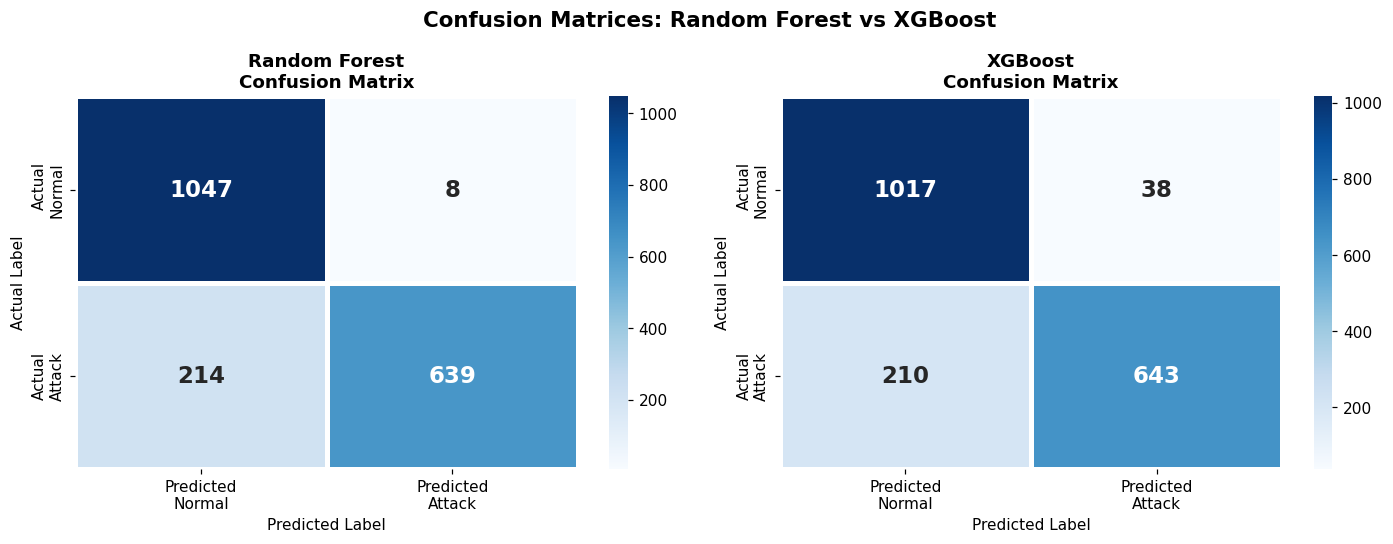

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, probs, name in [
    (axes[0], rf_preds,  rf_probs,  'Random Forest'),
    (axes[1], xgb_preds, xgb_probs, 'XGBoost')
]:
    cm = confusion_matrix(y_test, preds)
    # confusion_matrix returns a 2x2 array:
    #   [[TN, FP],
    #    [FN, TP]]

    # annot=True   : write numbers inside cells
    # fmt='d'      : format as integer (not scientific notation)
    # cmap='Blues' : colour scale from white (low) to blue (high)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted\nNormal', 'Predicted\nAttack'],
                yticklabels=['Actual\nNormal', 'Actual\nAttack'],
                annot_kws={'size': 15, 'weight': 'bold'},
                linewidths=2, linecolor='white')

    # Extract the four values
    tn, fp, fn, tp = cm.ravel()
    # .ravel() flattens [[TN,FP],[FN,TP]] into (TN, FP, FN, TP)

    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

    print(f'{name}:')
    print(f'  True  Negatives  (TN) = {tn:4d}  -- Normal correctly identified')
    print(f'  False Positives  (FP) = {fp:4d}  -- False alarms (normal flagged as attack)')
    print(f'  False Negatives  (FN) = {fn:4d}  -- MISSED ATTACKS (most dangerous!)')
    print(f'  True  Positives  (TP) = {tp:4d}  -- Attacks correctly caught')
    print(f'  Attack Detection Rate (Recall) = {tp/(tp+fn):.4f} ({tp/(tp+fn)*100:.2f}%)')
    print(f'  False Alarm Rate (FPR)         = {fp/(fp+tn):.4f} ({fp/(fp+tn)*100:.2f}%)')
    print()

plt.suptitle('Confusion Matrices: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()



# Explanation
Key interpretation:
FN: bottom-left cell = MISSED ATTACKS. In real deployment each FN is a real cyber-attack that slipped through undetected. We want this number as LOW as possible.
FP: top-right cell = False alarms wastes analyst time but causes no actual security breach.

# Classification Reports

The classification report gives per-class Precision, Recall, and F1-Score.
This is more informative than a single overall accuracy number.


In [17]:
print('=' * 60)
print('RANDOM FOREST — Classification Report')
print('=' * 60)
print(classification_report(y_test, rf_preds,
                             target_names=['Normal (0)', 'Attack (1)'],
                             digits=4))

print('=' * 60)
print('XGBOOST — Classification Report')
print('=' * 60)
print(classification_report(y_test, xgb_preds,
                             target_names=['Normal (0)', 'Attack (1)'],
                             digits=4))


RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

  Normal (0)     0.8303    0.9924    0.9041      1055
  Attack (1)     0.9876    0.7491    0.8520       853

    accuracy                         0.8836      1908
   macro avg     0.9090    0.8708    0.8781      1908
weighted avg     0.9006    0.8836    0.8808      1908

XGBOOST — Classification Report
              precision    recall  f1-score   support

  Normal (0)     0.8289    0.9640    0.8913      1055
  Attack (1)     0.9442    0.7538    0.8383       853

    accuracy                         0.8700      1908
   macro avg     0.8865    0.8589    0.8648      1908
weighted avg     0.8804    0.8700    0.8676      1908



# Explanation
our models socred  approximately 0.85 for the attack class which is very good.

METRIC DEFINITION:
    
precision : of all sessions predicted as Attack, what % were real attacks?
          High precision = fewer false alarms

recall    : of all real attacks, what % did the model catch?
             High recall = fewer missed attacks
            THIS IS THE MOST IMPORTANT METRIC in cybersecurity

f1-score  : harmonic mean of precision and recall
             Single balanced score; 1.0 = perfect, 0.0 = worst
support   : how many rows of that class exist in the test set
macro avg    : simple average across classes ignores class size
weighted avg : average weighted by class size accounts for imbalance

# ROC-AUC Comparison

The **ROC curve** (Receiver Operating Characteristic) shows the tradeoff between true positive rate and false positive rate


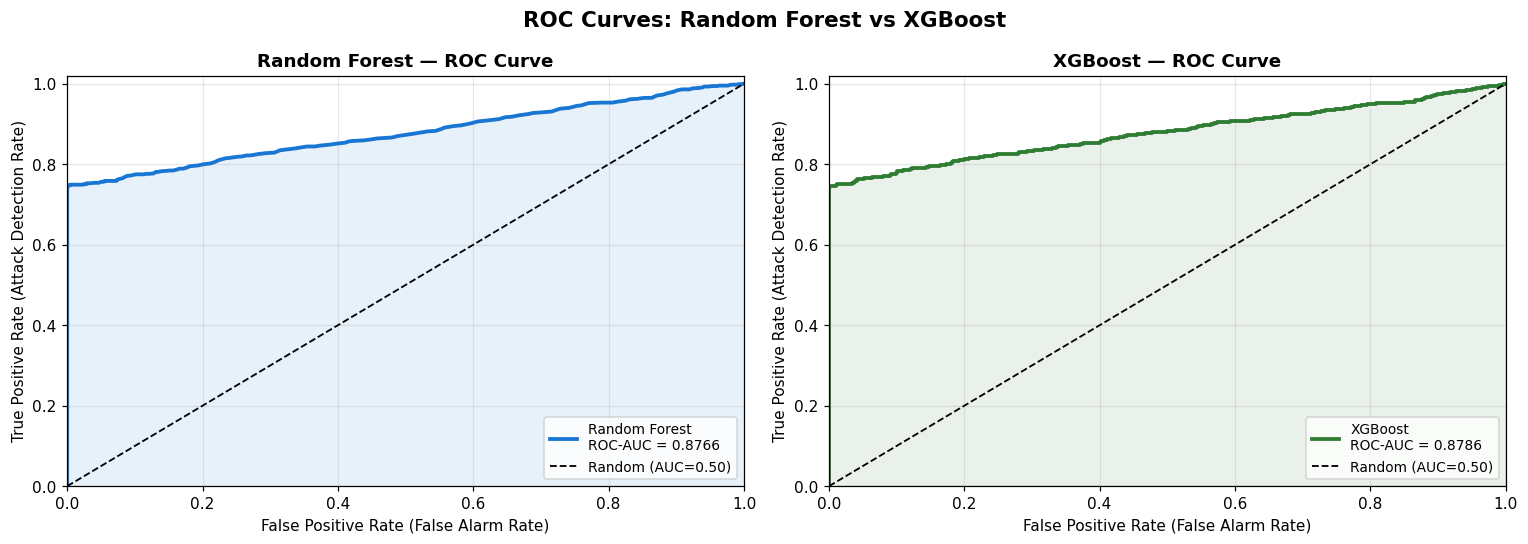

In [18]:
rf_rocauc  = roc_auc_score(y_test, rf_probs)
xgb_rocauc = roc_auc_score(y_test, xgb_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, name, color, rocauc in [
    (axes[0], rf_probs,  'Random Forest', '#1976D2', rf_rocauc),
    (axes[1], xgb_probs, 'XGBoost',       '#2E7D32', xgb_rocauc)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
   
    # roc_curve returns:
    #   fpr = false positive rates at each threshold
    #   tpr = true positive rates (recall) at each threshold

    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}\nROC-AUC = {rocauc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random (AUC=0.50)')  # diagonal baseline
    ax.fill_between(fpr, tpr, alpha=0.1, color=color)

    ax.set_title(f'{name} — ROC Curve', fontweight='bold', fontsize=12)
    ax.set_xlabel('False Positive Rate (False Alarm Rate)', fontsize=10)
    ax.set_ylabel('True Positive Rate (Attack Detection Rate)', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Explanation

The diagonal dashed line = random guessing (AUC = 0.5)
Our curve is far above the diagonal
The more the curve bows toward the top-left is better
AUC = area under the curve (shaded region)

# Complete Model Comparison Summary


In [19]:
# Building a comprehensive comparison table

from sklearn.metrics import f1_score, precision_score, recall_score

def get_metrics(y_true, y_pred, y_prob, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Model'            : name,
        'PR-AUC'           : round(average_precision_score(y_true, y_prob), 4),
        'ROC-AUC'          : round(roc_auc_score(y_true, y_prob), 4),
        'Precision(Attack)': round(precision_score(y_true, y_pred), 4),
        'Recall(Attack)'   : round(recall_score(y_true, y_pred), 4),
        'F1(Attack)'       : round(f1_score(y_true, y_pred), 4),
        'Missed Attacks(FN)': int(fn),
        'False Alarms(FP)' : int(fp),
        'Accuracy'         : round((tn + tp) / (tn + fp + fn + tp), 4),
    }

rf_metrics  = get_metrics(y_test, rf_preds,  rf_probs,  'Random Forest')
xgb_metrics = get_metrics(y_test, xgb_preds, xgb_probs, 'XGBoost')

comparison_df = pd.DataFrame([rf_metrics, xgb_metrics]).set_index('Model')
print('COMPLETE MODEL COMPARISON:')
print(comparison_df.T.to_string())
print()

# Highlight which model won on each metric
print('WINNER PER METRIC:')
for metric in ['PR-AUC', 'ROC-AUC', 'Recall(Attack)', 'F1(Attack)']:
    rf_val  = rf_metrics[metric]
    xgb_val = xgb_metrics[metric]
    if metric == 'Missed Attacks(FN)':
        winner = 'Random Forest' if rf_val < xgb_val else 'XGBoost'
    else:
        winner = 'Random Forest' if rf_val > xgb_val else 'XGBoost'
    print(f'  {metric:<25}: {winner}  (RF={rf_val}, XGB={xgb_val})')


COMPLETE MODEL COMPARISON:
Model               Random Forest   XGBoost
PR-AUC                     0.9063    0.9093
ROC-AUC                    0.8766    0.8786
Precision(Attack)          0.9876    0.9442
Recall(Attack)             0.7491    0.7538
F1(Attack)                 0.8520    0.8383
Missed Attacks(FN)       214.0000  210.0000
False Alarms(FP)           8.0000   38.0000
Accuracy                   0.8836    0.8700

WINNER PER METRIC:
  PR-AUC                   : XGBoost  (RF=0.9063, XGB=0.9093)
  ROC-AUC                  : XGBoost  (RF=0.8766, XGB=0.8786)
  Recall(Attack)           : XGBoost  (RF=0.7491, XGB=0.7538)
  F1(Attack)               : Random Forest  (RF=0.852, XGB=0.8383)


# Part 3: Explainable AI with SHAP

**SHAP** (SHapley Additive exPlanations) comes from cooperative game theory.
It assigns each feature a contribution score for each individual prediction.

- Positive SHAP value → this feature pushes the prediction TOWARD 'Attack'
- Negative SHAP value → this feature pushes the prediction TOWARD 'Normal'
- Large absolute value → this feature has a big influence on the prediction
- Near zero → this feature barely influences this prediction


In [20]:
# Initialise the SHAP TreeExplainer for XGBoost
#
# TreeExplainer is specially designed for tree-based models (Random Forest, XGBoost, etc.)
# It uses an exact algorithm (not an approximation) so results are mathematically precise
#
# Why XGBoost and not Random Forest for SHAP?
# XGBoost typically has higher predictive power, so understanding IT is more valuable
# Also, SHAP + XGBoost is the standard combination in the literature

print('Initialising SHAP TreeExplainer...')
explainer = shap.TreeExplainer(xgb_model)
# TreeExplainer(model) prepares the explainer -- learns the model structure

# Compute SHAP values for ALL test set rows
# This returns an Explanation object where:
#   .values       : matrix of shape (n_rows, n_features) -- SHAP score per feature per row
#   .base_values  : the model's baseline prediction (before any features are considered)
#   .data         : the actual feature values from X_test
print('Computing SHAP values for all test samples...')
print('(This may take 30-60 seconds)')
shap_values = explainer(X_test)

print(f'\nSHAP computation complete!')
print(f'SHAP values matrix shape : {shap_values.values.shape}')
print(f'  -> {shap_values.values.shape[0]} test rows  x  {shap_values.values.shape[1]} features')
print(f'Each cell = how much that feature pushed prediction up or down for that session')


Initialising SHAP TreeExplainer...
Computing SHAP values for all test samples...
(This may take 30-60 seconds)

SHAP computation complete!
SHAP values matrix shape : (1908, 14)
  -> 1908 test rows  x  14 features
Each cell = how much that feature pushed prediction up or down for that session


**Explanation:**
- `shap.TreeExplainer(xgb_model)` creates the explainer - it analyses the model's structure.
- `explainer(X_test)` runs SHAP for every row in the test set - this is the slow step.
- The result is a matrix with one SHAP score per feature per session.
- SHAP scores can be positive (pushed toward Attack) or negative (pushed toward Normal).


# Global SHAP Summary Plot (Dot Plot)

This plot shows ALL features ranked by average importance,
with each dot representing one test session.


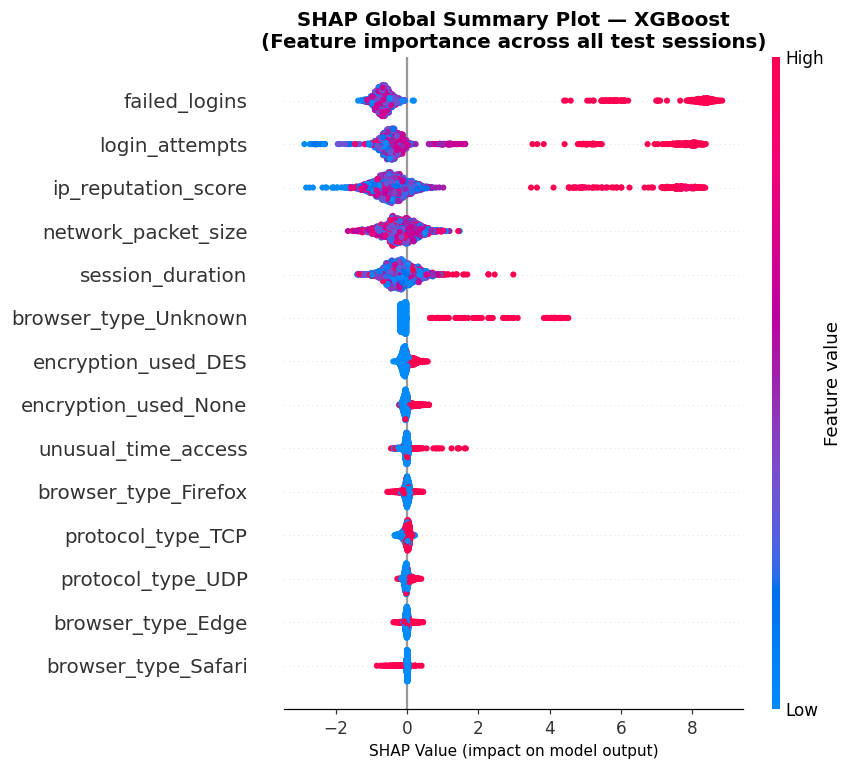

In [21]:
# GLOBAL SHAP SUMMARY PLOT

#   - Each ROW = one feature (ranked by importance, most important at top)
#   - Each DOT = one test session
#   - X-AXIS   = SHAP value
#                positive (right) = this feature pushed prediction toward ATTACK
#                negative (left)  = this feature pushed prediction toward NORMAL
#   - COLOUR   = actual value of that feature for that session
#                RED  = high feature value
#                BLUE = low feature value

plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Global Summary Plot — XGBoost\n(Feature importance across all test sessions)',
          fontweight='bold', fontsize=13)
plt.xlabel('SHAP Value (impact on model output)', fontsize=10)
plt.tight_layout()
plt.show()
print()

print()

print()



# Explanation
Explanation
RANKING (vertical axis):
 Features at the TOP have the most influence on predictions overall.
 Features at the BOTTOM barely affect the model.

COLOUR + POSITION 
what it means for each feature:
RED dots on the RIGHT  = high value of this feature = predicts ATTACK
Example: many failed_logins (red) pushes prediction toward Attack (right)

BLUE dots on the RIGHT = low value of this feature = predicts ATTACK
Example: low ip_reputation_score (blue) pushes prediction toward Attack (right)
Makes sense: low reputation = known bad IP = more likely attack)
Dots SPREAD widely = feature is consistently influential
Dots CLUSTERED near 0 = feature has little effect most of the time

# Global SHAP Bar Plot (Mean Absolute Impact)
This shows the average absolute SHAP value for each feature.


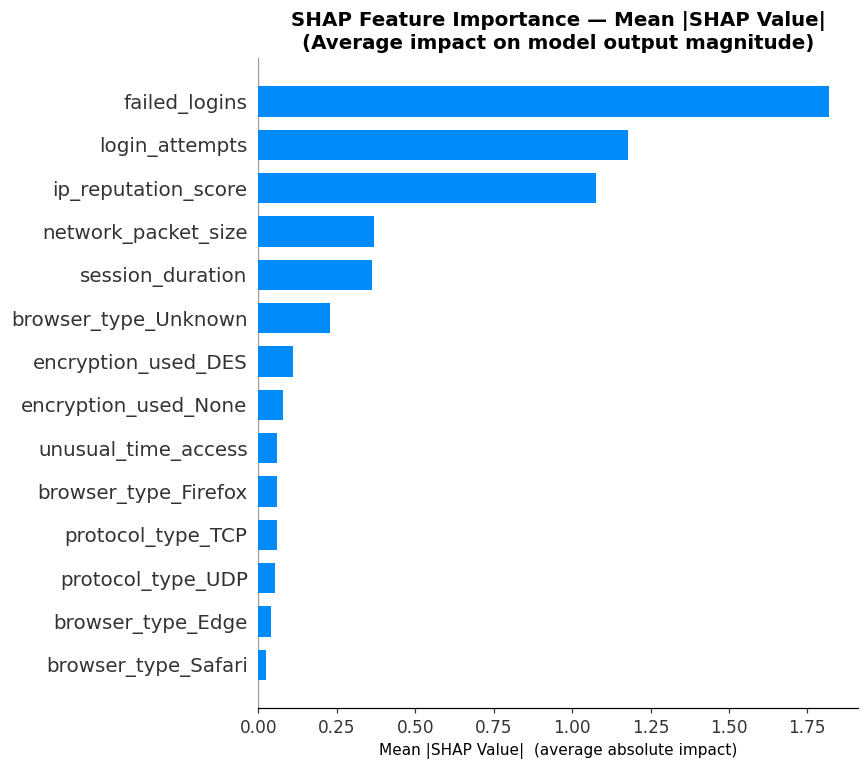

In [22]:
# GLOBAL SHAP BAR PLOT

# Bar length = average importance across all test sessions
# Longer bar = feature contributes more to predictions on average

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Mean |SHAP Value|\n(Average impact on model output magnitude)',
          fontweight='bold', fontsize=13)
plt.xlabel('Mean |SHAP Value|  (average absolute impact)', fontsize=10)
plt.tight_layout()
plt.show()


print()



# Explanation
Interpretation:
Longer bar = this feature has bigger influence on predictions on average.
Shorter bar = this feature adds little predictive power.

Security insight: the top features should align with our theoretical frameworks of CIA Triad and Cyber Kill Chain mapping e.g
If failed_logins is at the top = brute force IS the main attack pattern.
If ip_reputation_score is high = threat intelligence data is very useful.

# Local SHAP explanation; explaining one attack prediction

A waterfall plot shows exactly which features contributed to pushing the model's prediction
from the baseline up to the final attack probability.


In [23]:
# Find the test session with the highest predicted attack probability
# This is the session the model is most certain is an attack

row_index_attack = int(np.argmax(xgb_probs)) #returns the index of the maximum value in the array


actual_label   = int(y_test.iloc[row_index_attack])
pred_prob      = float(xgb_probs[row_index_attack])
pred_label     = int(xgb_preds[row_index_attack])

print(f'Explaining Test Session #{row_index_attack}')
print(f'  Actual label      : {"ATTACK" if actual_label == 1 else "Normal"} ({actual_label})')
print(f'  Predicted label   : {"ATTACK" if pred_label == 1 else "Normal"} ({pred_label})')
print(f'  Predicted prob    : {pred_prob:.4f} ({pred_prob*100:.2f}% attack probability)')
print(f'  Correct?          : {"YES" if actual_label == pred_label else "NO"}')
print()
print('Feature values for this session:')
session_features = X_test.iloc[row_index_attack]
#print(session_features.round(4).to_string())


Explaining Test Session #1212
  Actual label      : ATTACK (1)
  Predicted label   : ATTACK (1)
  Predicted prob    : 1.0000 (100.00% attack probability)
  Correct?          : YES

Feature values for this session:


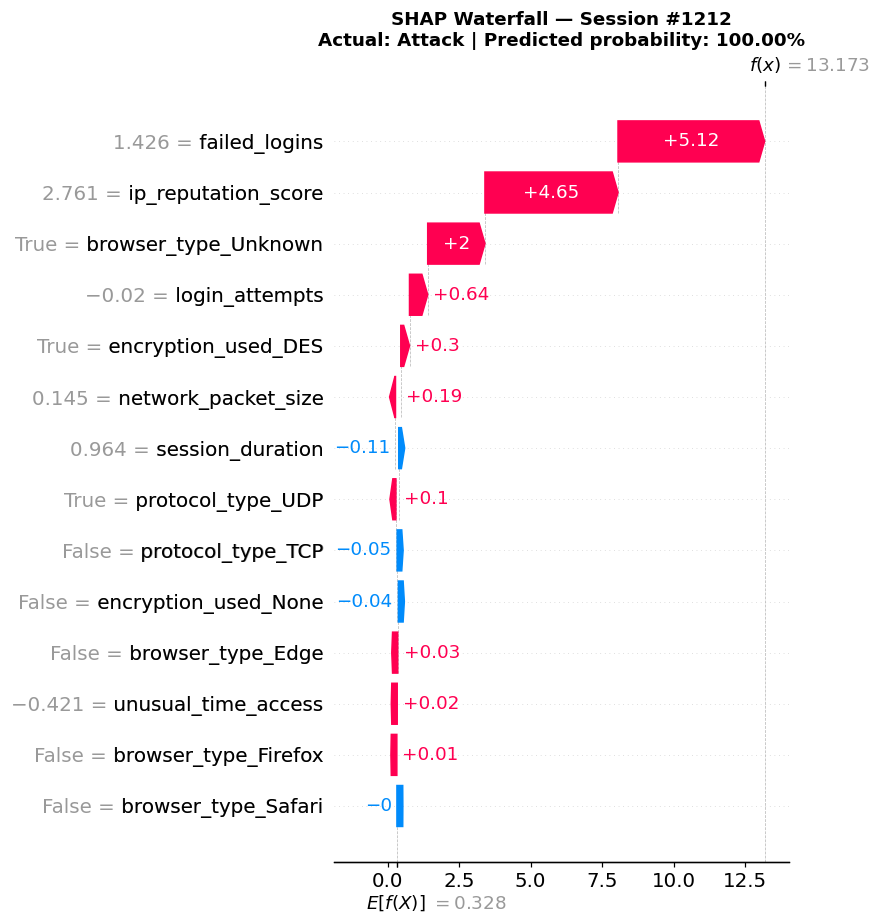

In [24]:
# WATERFALL PLOT for the attack session

#   E[f(X)]  at the BOTTOM = the model baseline
#            (average prediction across all sessions -- if the model knew nothing about THIS session)
#   f(x)     at the TOP    = the final prediction for THIS session
#
#   Each BAR represents one feature's contribution:
#   RED bar  (pointing RIGHT) = this feature INCREASED the attack probability
#   BLUE bar (pointing LEFT)  = this feature DECREASED the attack probability
#   BAR LENGTH = how much this feature pushed the prediction up or down
#
#   The bars STACK from the baseline to reach the final prediction

plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[row_index_attack], show=False, max_display=14)
plt.title(f'SHAP Waterfall — Session #{row_index_attack}\n'
          f'Actual: Attack | Predicted probability: {pred_prob*100:.2f}%',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


print()

print()

print()

print()

print()



# Explanation
Interpretation:

Bottom value E[F(X)] = model baseline: This is the average attack probability across all sessions
Before looking at this specific session, the model starts here

Top value f(x) = final prediction for this session
This is the actual attack probability the model assigned

RED bars (right): these features RAISED the attack probability
Example: failed_logins = 4 (high) -> strong evidence of brute force

BLUE bars (left): these features LOWERED the attack probability
Example: encryption_used = AES -> model slightly reduces suspicion

The bars accumulate from baseline to final prediction
Reading them top-to-bottom shows the reasoning chain:"Start at baseline, add these factors, subtract those, arrive at final score"')

# Local waterfall SHAP plot Normal session


In [25]:
# Finding the test session with the lowest predicted attack probability
# This is the session the model is most certain is normal/safe

row_index_normal = int(np.argmin(xgb_probs))
actual_normal    = int(y_test.iloc[row_index_normal])
pred_prob_normal = float(xgb_probs[row_index_normal])

print(f'Explaining Test Session #{row_index_normal} (Normal for example)')
print(f'  Actual label      : {"ATTACK" if actual_normal == 1 else "Normal"} ({actual_normal})')
print(f'  Predicted prob    : {pred_prob_normal:.4f} ({pred_prob_normal*100:.2f}% attack probability)')
print()
print('Feature values for this session:')
print(X_test.iloc[row_index_normal].astype(float).round(4).to_string())

Explaining Test Session #1112 (Normal for example)
  Actual label      : Normal (0)
  Predicted prob    : 0.0031 (0.31% attack probability)

Feature values for this session:
network_packet_size     1.3906
login_attempts         -0.5246
session_duration       -0.5654
ip_reputation_score     0.8803
failed_logins          -1.4692
unusual_time_access    -0.4209
protocol_type_TCP       1.0000
protocol_type_UDP       0.0000
encryption_used_DES     0.0000
encryption_used_None    0.0000
browser_type_Edge       0.0000
browser_type_Firefox    1.0000
browser_type_Safari     0.0000
browser_type_Unknown    0.0000


# Explanation

The purpose of showing both the attack waterfall and the normal waterfall is comparison. By looking at both side by side you can identify what distinguishes attacks from normal sessions in the model's reasoning. The normal session waterfall should be dominated by BLUE bars (features pushing toward Normal).

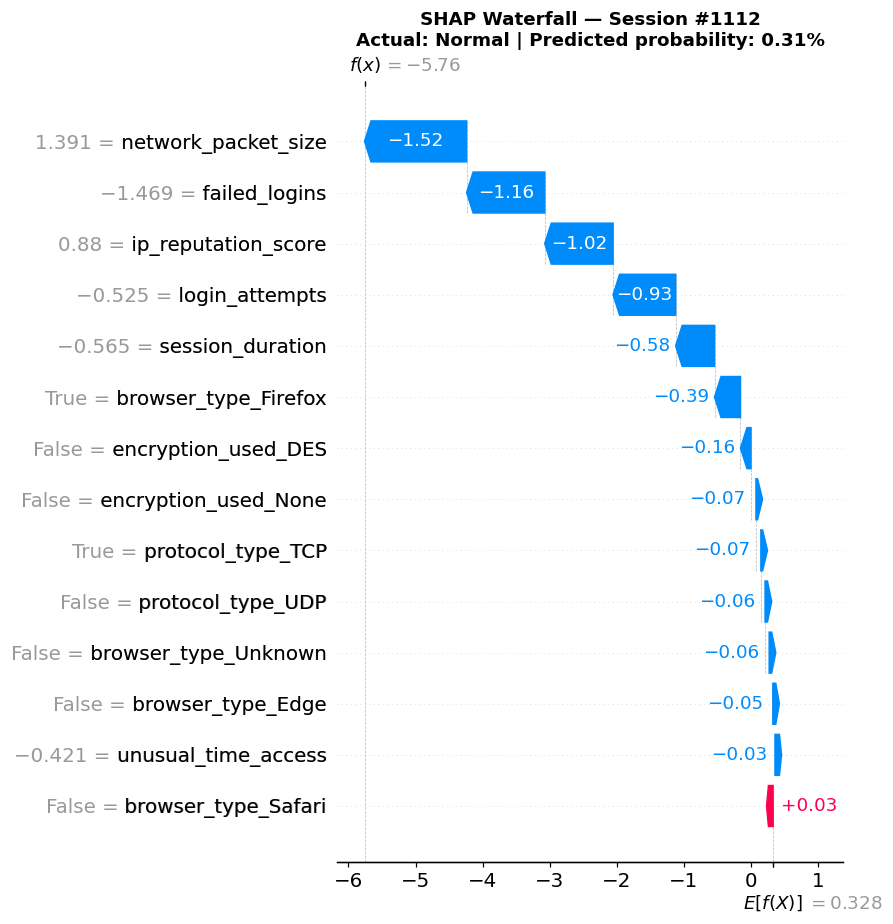

In [26]:
plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[row_index_normal], show=False, max_display=14)
plt.title(f'SHAP Waterfall — Session #{row_index_normal}\n'
          f'Actual: Normal | Predicted probability: {pred_prob_normal*100:.2f}%',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


print()

print()

print()

print()

print()

# Explanation

INTERPRETATION OF THE WATERFALL PLOT (Normal session):

Compare this to the Attack waterfall in section 4c.

In the Normal session, BLUE bars should dominate:
Blue = features pulling the prediction DOWN toward Normal

The final f(x) at the top should be CLOSE TO 0 (low attack probability)

What makes this session look safe?
- Low failed_logins (e.g., 0 or 1) -> no sign of brute force
- High ip_reputation_score         -> this IP is known to be legitimate
- Normal session_duration           -> no evidence of data exfiltration
- Strong encryption (AES)           -> properly secured session
This is the model saying: "Nothing suspicious here; let it through."


# SHAP dependence Plot

A dependence plot shows how a single feature's value affects its SHAP score across all test sessions. 
This reveals the relationship the model actually learned between that feature and attack probability.


Top 2 features by mean |SHAP|: ['failed_logins', 'login_attempts']



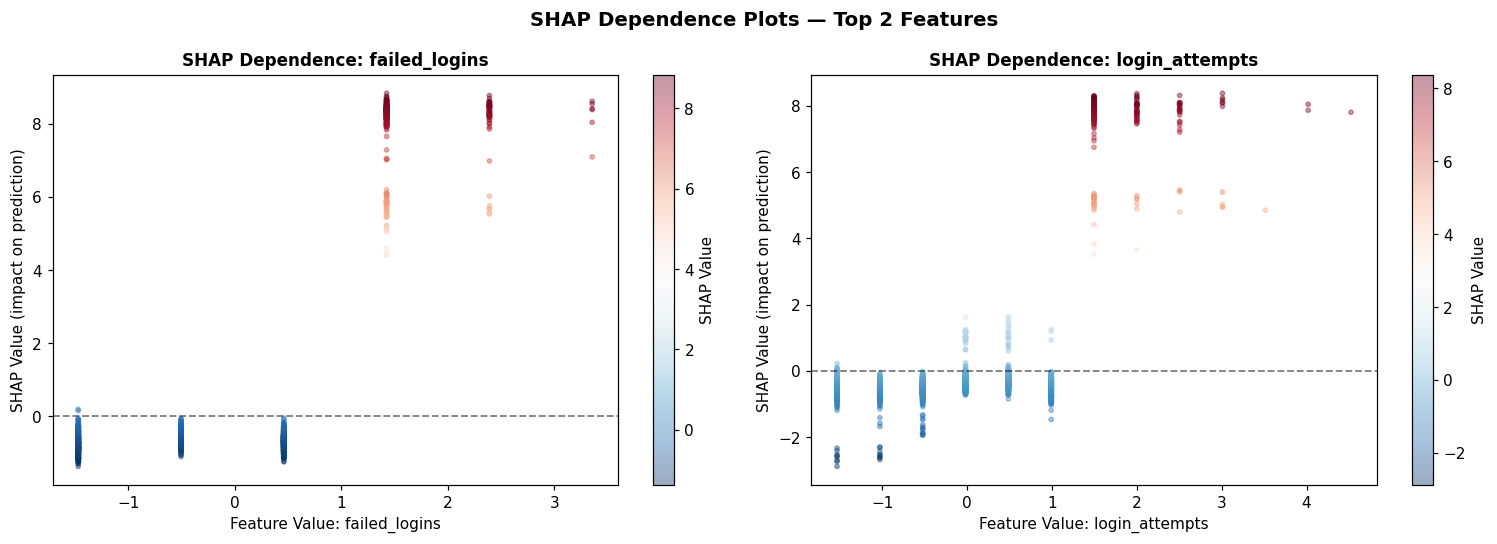

In [27]:
# SHAP DEPENDENCE PLOT
#
# We plot the most important feature (failed_logins or ip_reputation_score)
# X-axis = actual value of the feature for each session
# Y-axis = SHAP value (how much that feature pushed the prediction up or down)
# Colour = value of an automatically-selected interaction feature
#
# The trend line shows: as the feature value increases/decreases,
# how does it affect the model's attack prediction?

# Identifying the top 2 features by mean absolute SHAP value
mean_shap = np.abs(shap_values.values).mean(axis=0)
# mean(axis=0) averages across all rows (test sessions) for each feature
top_features_idx = np.argsort(mean_shap)[::-1]  # sort descending
top_feature_names = [X_test.columns[i] for i in top_features_idx[:2]]

print(f'Top 2 features by mean |SHAP|: {top_feature_names}')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature_name in zip(axes, top_feature_names):
    feature_idx = list(X_test.columns).index(feature_name)

    feature_vals = shap_values.data[:, feature_idx]   # actual feature values
    shap_vals    = shap_values.values[:, feature_idx]  # SHAP values for this feature

    scatter = ax.scatter(
        feature_vals, shap_vals,
        c=shap_vals,              # colour by SHAP value (red=high, blue=low)
        cmap='RdBu_r',
        alpha=0.4,
        s=8
    )
    ax.axhline(y=0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
    ax.set_xlabel(f'Feature Value: {feature_name}', fontsize=10)
    ax.set_ylabel('SHAP Value (impact on prediction)', fontsize=10)
    ax.set_title(f'SHAP Dependence: {feature_name}', fontweight='bold', fontsize=11)
    plt.colorbar(scatter, ax=ax, label='SHAP Value')

plt.suptitle('SHAP Dependence Plots — Top 2 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Explanation
INTERPRETATION:
X-axis  = the actual value of this feature for each test session
Y-axis  = the SHAP value (how much this feature affected the prediction)
Above 0 = feature pushed prediction toward Attack
Below 0 = feature pushed prediction toward Normal

The TREND shows what relationship the model learned:
For failed_logins: as value increases = SHAP value increases = More failed logins = stronger prediction of Attack (positive relationship)

For ip_reputation_score: as value increases = SHAP value decreases = Higher reputation = less likely to be Attack (negative/inverse relationship)